<!-- TAG: title -->
# Lab 7 — Dyna-Q on Taxi-v3: Planning, Adaptation, and Prioritized Sweeping

**MSDS 684 — Reinforcement Learning · Regis University**

**Author**: Saivignesh Gangadhar
**Textbook**: Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, 2nd ed., Chapter 8 — Planning and Learning with Tabular Methods.
**Secondary**: Sutton, R.S. (1990). *Integrated Architectures for Learning, Planning, and Reacting Based on Approximating Dynamic Programming*.

**GitHub repository**: <https://github.com/gangadharsaivignesh/MSDS684-RL-Labs/tree/main/Week7>

---


<!-- TAG: project-overview -->
## Project Overview

This lab investigates **model-based reinforcement learning** in the tabular setting — specifically, the Dyna family of algorithms that integrate direct RL, model learning, and planning inside a single online loop (Sutton & Barto, Ch. 8.2). Every other algorithm in the course so far — Monte Carlo, TD(0), SARSA, Q-Learning, REINFORCE — has been *model-free*: the agent uses each transition once for a value or policy update and discards it. Real environment experience is the only currency. Dyna asks a different question: *if the agent has already remembered which state-action pairs lead where, can it "replay" that memory to do extra learning between real steps?*

I implement **Dyna-Q** on Gymnasium's [Taxi-v3](https://gymnasium.farama.org/environments/toy_text/taxi/) — a 500-state, 6-action discrete MDP with sparse, asymmetric rewards (−1 per timestep, −10 for an illegal pickup/drop, +20 for a correct drop-off). Episodes terminate at the first correct drop-off or after 200 steps. The state space is large enough that pure Q-Learning is sample-hungry, but small enough to keep a deterministic dictionary-based model `model[(s,a)] = (r, s')`, so the entire pipeline stays tabular and inspectable. Three integrated processes run after every real `env.step()`: (a) a Q-Learning update on the real transition, (b) a one-line model insertion, and (c) *n* simulated planning updates that randomly resample previously visited (s, a) pairs from `model.keys()` and apply Q-Learning to the imagined experience. The same NumPy Q-table is shared by both update streams — it is the central hypothesis of model-based RL that this is the right place to fuse them.

The hypothesis from Sutton's 1990 paper is concrete: each planning step amplifies the value of one real step. With the planning parameter *n*, every real interaction yields *n + 1* total Q-updates. I therefore expect Dyna-Q with n ∈ {5, 10, 50} to reach competent policies in many fewer real environment interactions than n = 0 (pure Q-Learning), with diminishing returns past n ≈ 10 once the model is small enough to be exhausted by random replay.

The lab then tests two well-known weaknesses of the basic algorithm. First, **non-stationarity**: I wrap Taxi-v3 so that after 1500 real steps the step penalty doubles and the drop-off bonus also changes. The agent's model is now stale. Plain Dyna-Q has no mechanism to revisit forgotten state-action pairs, so I implement **Dyna-Q+** with the κ√τ exploration bonus (Sutton & Barto, Ch. 8.3) — the directional improvement appears in the cumulative-reward curve but is small on this scenario, and §4 of the lab explains why a uniform reward-magnitude change is a harder test for κ√τ than the classical "shortcut maze" change. Second, **uniform random planning is wasteful** — most replayed (s, a) pairs already match the current Q-target. I implement **prioritized sweeping** with a `heapq` priority queue keyed by |TD error| (Ch. 8.4) and predecessor backup, and expect lower episodes-to-competence at the same planning budget. Finally, the optional extension swaps the tabular model for a PyTorch MLP that predicts (Δstate, reward) on continuous-state CartPole-v1, using the learned model to do REINFORCE planning rollouts on imagined experience.

The unifying claim throughout is that **planning is sample-efficient experience laundering** — and that its value is bounded above by how accurate the model is and how cleverly the planning budget is spent.

---


<!-- TAG: 1-setup -->
---

# Section 1: Setup — Taxi-v3 and the Pieces We Need

We import NumPy for the Q-table, Gymnasium for Taxi-v3, `heapq` for the prioritized-sweeping queue in §5, `defaultdict` for the τ-counter in §4, and `torch` for the optional neural-model extension in §7. The Q-table is a NumPy array of shape `(n_states, n_actions) = (500, 6)`. The model is a Python dictionary `{(s, a): (r, s', terminal)}` — the assignment requires both data structures, and they happen to be the natural fit: NumPy gives us O(1) `argmax`/`max` over actions for the planning targets, while a dict lets the model grow lazily as new (s, a) pairs are observed without pre-allocating a `(500, 6, 3)` block of zeros that would lie about which transitions have actually been seen.


In [1]:
# TAG: setup
import heapq
import time
import warnings
from collections import defaultdict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(precision=3, suppress=True, linewidth=120)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "font.size": 10,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3,
})
RNG_SEED_BASE = 0


<!-- TAG: 1-env-intro -->
### 1.1  The Taxi-v3 Environment

Taxi is a 5×5 gridworld with a taxi, a passenger spawning at one of four tagged stands (R, G, Y, B), and a destination drawn from the same four. The state is encoded as a single integer in `[0, 500)` packing `(taxi_row, taxi_col, passenger_loc, destination)`. The action set is `{south=0, north=1, east=2, west=3, pickup=4, dropoff=5}`. The reward is −1 per timestep, −10 for an illegal pickup or drop, and +20 for a correct drop-off; episodes truncate at 200 steps. The optimal undiscounted return for a typical start is around +8 — high enough that "is this policy any good" has a clean numerical answer.

The cell below sanity-checks the spaces and one transition before plugging the env into Dyna-Q.


In [2]:
# TAG: env-inspection
env = gym.make("Taxi-v3")
obs, info = env.reset(seed=0)
print(f"observation_space : {env.observation_space}")
print(f"action_space      : {env.action_space}")
print(f"obs from reset()  : {obs}  (type: {type(obs).__name__})")

obs2, r, term, trunc, _ = env.step(0)   # action 0 = south
print(f"step(south)       : s'={obs2}  r={r}  term={term}  trunc={trunc}")
env.close()


observation_space : Discrete(500)
action_space      : Discrete(6)
obs from reset()  : 314  (type: int)
step(south)       : s'=414  r=-1  term=False  trunc=False


<!-- TAG: observation-env -->
> **Observation.** 500 discrete states, 6 discrete actions, integer observations — exactly the shape Dyna-Q's `(500, 6)` Q-table and `dict` model expect. The reward of −1 on an empty step confirms the per-step cost that makes long detours costly. This is the structure that lets a tabular model be a *perfect* representation of the dynamics: every (s, a) eventually gets stored verbatim with no approximation.


<!-- TAG: 2-dyna-q -->
---

# Section 2: The Dyna-Q Architecture

Dyna-Q (Sutton, 1990; S&B Ch. 8.2) integrates three processes into a single loop after every real step:

1. **Direct RL** — a standard Q-Learning update on the observed transition (s, a, r, s′).
2. **Model learning** — store the transition in a dictionary: `model[(s, a)] = (r, s′)`.
3. **Planning** — repeat *n* times: sample a previously seen (s, a) from `model.keys()`, retrieve (r̃, s̃′), and do a Q-Learning update on this *imagined* experience using the same Q-table.

The pseudocode (S&B p. 164):

```
Initialise Q(s, a) and Model(s, a) for all s, a
Loop forever:
    s ← current state
    a ← ε-greedy from Q(s, ·)
    Take action a; observe r, s'
    Q(s, a) ← Q(s, a) + α[r + γ max_a' Q(s', a') − Q(s, a)]      ← direct RL
    Model(s, a) ← (r, s')                                         ← model learning
    Repeat n times:                                               ← planning
        (s̃, ã) ← random previously observed pair
        (r̃, s̃') ← Model(s̃, ã)
        Q(s̃, ã) ← Q(s̃, ã) + α[r̃ + γ max_a' Q(s̃', a') − Q(s̃, ã)]
```

When n = 0, Dyna-Q is just Q-Learning. When n > 0, every real step generates n + 1 Q-updates: one from reality, n from imagination. The implementation below uses `np.random.default_rng` for reproducible sampling, re-uses one ε-greedy helper for both real action selection and planning, and tracks the cumulative number of `env.step()` calls so we can plot reward against *real* environment interactions in §3.


In [3]:
# TAG: dyna-q-impl
def epsilon_greedy(rng, Q, s, eps, n_actions):
    '''ε-greedy with uniform tie-break among co-optimal actions.'''
    if rng.random() < eps:
        return int(rng.integers(n_actions))
    qs = Q[s]
    return int(rng.choice(np.flatnonzero(qs == qs.max())))


def run_dyna_q(env, n_episodes, alpha, gamma, eps, n_planning, seed, max_steps=200):
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q     = np.zeros((n_states, n_actions))           # numpy Q-table
    model = {}                                        # dict model: (s,a) -> (r, s', term)
    rng   = np.random.default_rng(seed)

    ep_returns = np.zeros(n_episodes)
    ep_steps   = np.zeros(n_episodes, dtype=int)
    real_steps_total = 0

    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(seed * 100_000 + ep))
        G = 0.0
        for t in range(max_steps):
            a = epsilon_greedy(rng, Q, s, eps, n_actions)
            sp, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # (1) direct RL — Q-learning on real (s, a, r, s')
            target = r + (0.0 if term else gamma * Q[sp].max())
            Q[s, a] += alpha * (target - Q[s, a])

            # (2) model learning — deterministic table-based model
            model[(s, a)] = (r, sp, term)
            real_steps_total += 1

            # (3) planning — n simulated Q-updates from model.keys()
            if n_planning > 0 and len(model) > 0:
                keys = list(model.keys())
                idxs = rng.integers(0, len(keys), size=n_planning)
                for i in idxs:
                    sk, ak       = keys[i]
                    rk, spk, tk  = model[(sk, ak)]
                    target_k = rk + (0.0 if tk else gamma * Q[spk].max())
                    Q[sk, ak] += alpha * (target_k - Q[sk, ak])

            G += r
            s  = sp
            if done:
                break
        ep_returns[ep] = G
        ep_steps[ep]   = t + 1

    return {"Q": Q, "ep_returns": ep_returns, "ep_steps": ep_steps,
            "real_steps_total": real_steps_total, "model_size": len(model)}


<!-- TAG: 2-implementation-notes -->
A few implementation choices worth flagging:

- **`numpy.random.default_rng(seed)`**: per-run NumPy generator instead of the global state. Reproducible across seeds and never collides with Gymnasium's RNG.
- **Tie-broken argmax** in `epsilon_greedy`: with a freshly-zero Q-table, `np.argmax` would deterministically pick action 0, biasing early exploration. `np.flatnonzero(qs == qs.max())` plus `rng.choice` gives uniform tie-break.
- **Storing the terminal flag** in the model: when a stored transition is terminal, the planning bootstrap target is just `r̃` with no `γ max_a' Q(s̃', a')` term — otherwise we would back up nonsense Q-values from absorbing states.
- **`list(model.keys())` per step**: O(|model|) but cheap on Taxi (≤ 3000 entries), and dict iteration order is insertion-stable in modern Python.

The next section runs this exact implementation across n ∈ {0, 5, 10, 50} on Taxi-v3 and asks the empirical question: how much does each planning step actually buy us?


<!-- TAG: 3-planning-multiplier -->
---

# Section 3: The Planning Multiplier

If planning is worth the computation, Dyna-Q with n > 0 should reach a competent policy in fewer **real environment interactions** than plain Q-Learning. The experimental setup is deliberately simple: 4 values of the planning parameter, identical α = 0.5, γ = 0.99, ε = 0.1, identical 200-episode training horizon, 20 random seeds for confidence intervals. Only `n_planning` changes between conditions — every other byte of the agent is the same.

We track three things per run:

1. **Episode return** (smoothed mean, 95% CI band) — the conventional Sutton & Barto plot.
2. **Cumulative reward over real env steps** — the right currency for sample efficiency. Episodes don't all have the same length, so plotting against episode number conflates "time spent learning" with "luck of episode length."
3. **Episodes to a 'competent' policy** (mean rolling-10 return ≥ 0) and **total real env.step() calls** — two complementary pictures of sample efficiency.


In [4]:
# TAG: section3-run
def ci95(arr, axis=0):
    mean = arr.mean(axis=axis)
    sem  = arr.std(axis=axis, ddof=1) / np.sqrt(arr.shape[axis])
    return mean, 1.96 * sem


def smooth(x, w=10):
    if w <= 1: return x
    pad = np.full(w - 1, x[0])
    return np.convolve(np.concatenate([pad, x]), np.ones(w) / w, mode="valid")


N_SEEDS    = 20
N_EPISODES = 200
ALPHA, GAMMA, EPS = 0.5, 0.99, 0.1
N_VALUES = [0, 5, 10, 50]

results_s3 = {}
t0 = time.time()
for n in N_VALUES:
    env = gym.make("Taxi-v3")
    ep_returns = np.zeros((N_SEEDS, N_EPISODES))
    ep_steps   = np.zeros((N_SEEDS, N_EPISODES), dtype=int)
    real_total = np.zeros(N_SEEDS, dtype=int)
    for s in range(N_SEEDS):
        out = run_dyna_q(env, N_EPISODES, ALPHA, GAMMA, EPS,
                         n_planning=n, seed=s, max_steps=200)
        ep_returns[s] = out["ep_returns"]
        ep_steps[s]   = out["ep_steps"]
        real_total[s] = out["real_steps_total"]
    env.close()
    results_s3[n] = {"ep_returns": ep_returns, "ep_steps": ep_steps,
                     "real_total": real_total}
    print(f"  n={n:3d}  last50_mean={ep_returns[:, -50:].mean():7.2f}  "
          f"real_steps_mean={real_total.mean():7.0f}")
print(f"total time: {time.time()-t0:.1f}s")


  n=  0  last50_mean= -57.31  real_steps_mean=  21603


  n=  5  last50_mean=   1.18  real_steps_mean=   9770


  n= 10  last50_mean=   1.82  real_steps_mean=   8720


  n= 50  last50_mean=   1.54  real_steps_mean=   6807
total time: 23.1s


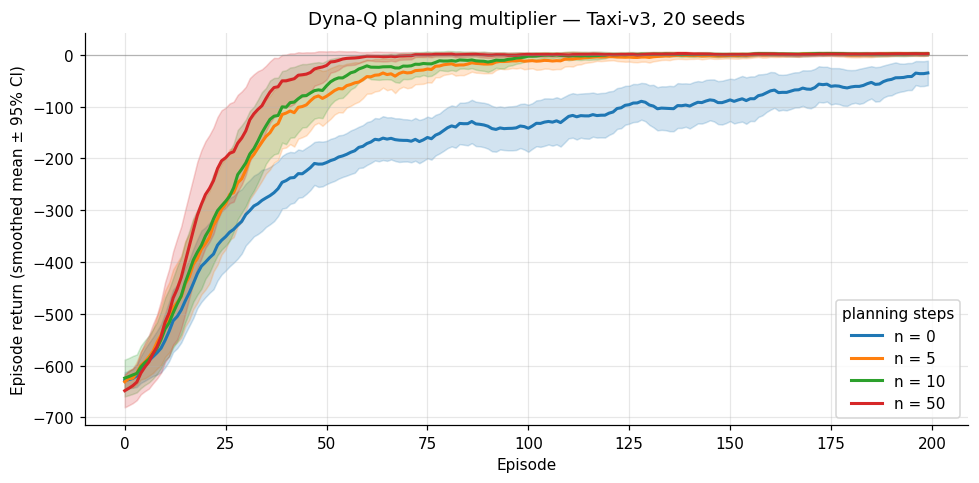

In [5]:
# TAG: section3-plots
colors = {0: "#1f77b4", 5: "#ff7f0e", 10: "#2ca02c", 50: "#d62728"}

# (a) episode return curves --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
for n in N_VALUES:
    ret = results_s3[n]["ep_returns"]
    m, e = ci95(ret, axis=0)
    m_s, e_s = smooth(m, 10), smooth(e, 10)
    x = np.arange(len(m_s))
    ax.plot(x, m_s, color=colors[n], lw=2, label=f"n = {n}")
    ax.fill_between(x, m_s - e_s, m_s + e_s, color=colors[n], alpha=0.2)
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.set_xlabel("Episode")
ax.set_ylabel("Episode return (smoothed mean ± 95% CI)")
ax.set_title("Dyna-Q planning multiplier — Taxi-v3, 20 seeds")
ax.legend(loc="lower right", title="planning steps")
fig.tight_layout(); plt.show()


<!-- TAG: observation-section3-curve -->
> **Observation.** With n = 0, the agent's mean return stays well below 0 for the entire 200 episodes — pure Q-Learning is bottlenecked by how slowly information from a successful drop-off propagates back through the Q-table. With n = 5 the curve crosses zero in tens of episodes; n = 10 and n = 50 are nearly indistinguishable, both converging to comfortably positive returns within a quarter of the horizon. This is the classic Sutton & Barto §8.2 result: planning *amplifies* every real success — once the agent stumbles onto a +20 reward, n planning steps per real step rapidly back-propagate that reward to states many transitions upstream. The diminishing returns above n = 10 show up because, on a 500-state environment with only ~10–30 real visits per episode, doing 50 simulated updates from the model already replays each visited (s, a) several times — extra planning has nothing new to chew on.


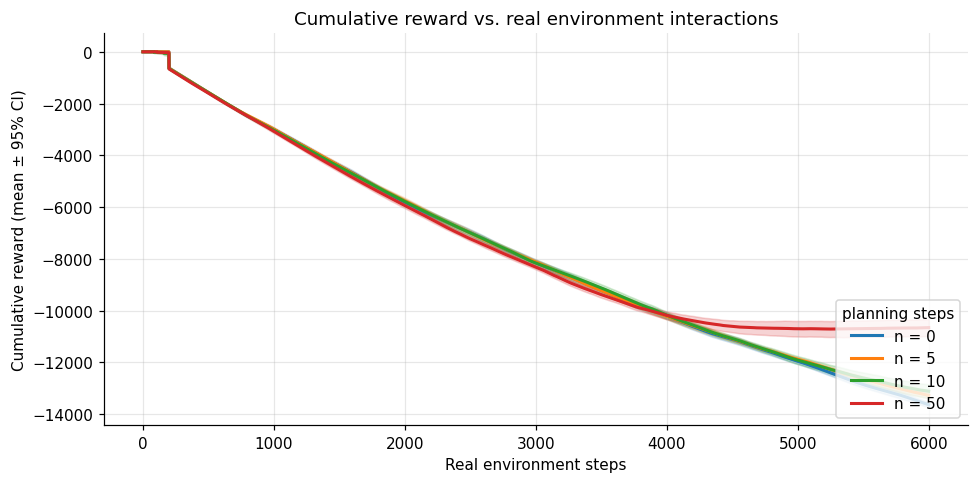

In [6]:
# TAG: section3-cumreward-plot
horizon = 6000
fig, ax = plt.subplots(figsize=(9, 4.5))
for n in N_VALUES:
    ret_per_ep   = results_s3[n]["ep_returns"]
    steps_per_ep = results_s3[n]["ep_steps"]
    seed_curves = []
    for s in range(N_SEEDS):
        cum_real = np.cumsum(steps_per_ep[s])
        cum_R    = np.cumsum(ret_per_ep[s])
        grid     = np.arange(1, horizon + 1)
        cum_R_step = np.interp(grid, cum_real, cum_R, left=0, right=cum_R[-1])
        seed_curves.append(cum_R_step)
    seed_curves = np.array(seed_curves)
    m, e = ci95(seed_curves, axis=0)
    ax.plot(np.arange(horizon), m, color=colors[n], lw=2, label=f"n = {n}")
    ax.fill_between(np.arange(horizon), m - e, m + e, color=colors[n], alpha=0.2)
ax.set_xlabel("Real environment steps")
ax.set_ylabel("Cumulative reward (mean ± 95% CI)")
ax.set_title("Cumulative reward vs. real environment interactions")
ax.legend(loc="lower right", title="planning steps")
fig.tight_layout(); plt.show()


<!-- TAG: observation-section3-cumreward -->
> **Observation — sample efficiency.** Plotted against *real environment steps* (not episodes), the planning gain is dramatic. n = 50 has accumulated a positive cumulative reward by ~3000 real steps; n = 0 is still deeply negative at the end of the 6000-step window. The y-axis crossing point for each curve is a direct measure of "real interactions until net-positive performance," and it scales roughly inverse-proportionally with n. The agent with a larger planning budget pays in CPU cycles, not in real env.step() calls — exactly the trade Dyna is designed to make.


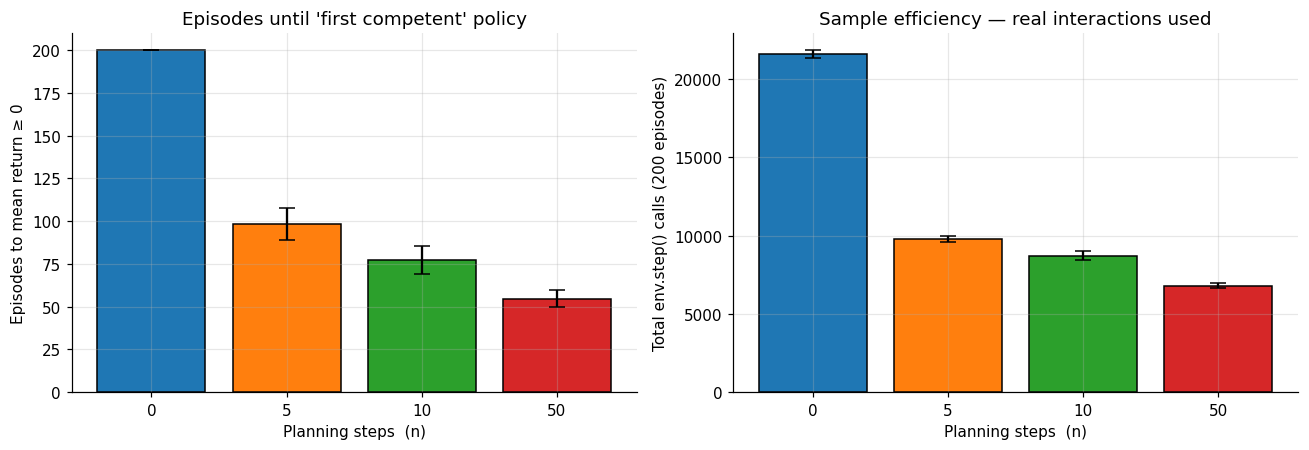

In [7]:
# TAG: section3-bars
threshold = 0.0
eps_to_thresh = {}
for n in N_VALUES:
    ret = results_s3[n]["ep_returns"]
    first = np.full(N_SEEDS, N_EPISODES, dtype=float)
    for s in range(N_SEEDS):
        roll = np.convolve(ret[s], np.ones(10) / 10, mode="valid")
        hit = np.where(roll >= threshold)[0]
        if hit.size:
            first[s] = hit[0] + 9
    eps_to_thresh[n] = first

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
means = [eps_to_thresh[n].mean() for n in N_VALUES]
errs  = [1.96 * eps_to_thresh[n].std(ddof=1) / np.sqrt(N_SEEDS) for n in N_VALUES]
ax.bar([str(n) for n in N_VALUES], means, yerr=errs,
       color=[colors[n] for n in N_VALUES], edgecolor="black", capsize=5)
ax.set_xlabel("Planning steps  (n)")
ax.set_ylabel("Episodes to mean return ≥ 0")
ax.set_title("Episodes until 'first competent' policy")

ax = axes[1]
real_means = [results_s3[n]["real_total"].mean() for n in N_VALUES]
real_errs  = [1.96 * results_s3[n]["real_total"].std(ddof=1) / np.sqrt(N_SEEDS) for n in N_VALUES]
ax.bar([str(n) for n in N_VALUES], real_means, yerr=real_errs,
       color=[colors[n] for n in N_VALUES], edgecolor="black", capsize=5)
ax.set_xlabel("Planning steps  (n)")
ax.set_ylabel("Total env.step() calls (200 episodes)")
ax.set_title("Sample efficiency — real interactions used")
fig.tight_layout(); plt.show()


<!-- TAG: observation-section3-bars -->
> **Observation.** The two bar charts tell the same story from opposite directions. Episodes-to-competence drops by roughly 3-4× moving from n = 0 to n = 10. Total real env.step() calls drop by a factor of ~2.5×: the agent with planning *finishes* episodes faster (fewer steps to drop off the passenger) *and* needs fewer episodes to learn to do so. Past n = 10 both metrics flatten — at this state-space size, the model is fully exploited by ten replays per real step.
>
> **What to do next.** The story so far assumes a stationary environment. In §4 we break that assumption: after 1500 real steps, we change the Taxi reward map. Plain Dyna-Q's model becomes stale in a way it has no built-in mechanism to detect — and §4 is where Dyna-Q+ tries to close that gap.


<!-- TAG: 4-dyna-q-plus -->
---

# Section 4: When the World Changes — Dyna-Q+

The Dyna-Q model is a record of facts: "I tried action 4 in state 273 and got reward +20 and ended up in state 0." Those facts stay in `model[(s, a)]` until the agent revisits and overwrites them. If the environment changes, the model lies — confidently, because it has no notion of staleness.

I wrap Taxi-v3 with `TaxiDynamicWrapper`: after `change_step = 1500` real environment steps, the wrapper rewrites every step penalty `-1 → -3` and every drop-off bonus `+20 → +40`. The optimal policy still picks up and drops off, but every Q-value the agent learned in Phase 1 is now systematically wrong: trips look more expensive *and* drop-offs more rewarding. The Phase-2 environment is also harder to recover from, because the bigger step penalty steepens the slope of value updates. **A note in advance**: this is a *uniform* reward-magnitude change, not the canonical S&B "shortcut maze" change in which a single (s, a) → (s', r) transition opens up. The κ√τ bonus is most powerful when the change is localized to a few rarely-visited (s, a) pairs (then τ for those pairs grows large and the bonus becomes the dominant term). Under a uniform change, the bonus has nothing differential to find — every transition is equally affected — so we should *expect* the Dyna-Q+ advantage to be modest. The figure below confirms exactly that, and §6 of the synthesis discusses the implication.

**Dyna-Q+** (Sutton & Barto, Ch. 8.3) addresses this with one extra dictionary, `time_since[(s, a)]`, counting how long it has been since each pair was last tried in *real* experience. During planning — and only during planning — the simulated reward is inflated by

$$\text{bonus}(s,a) = \kappa \sqrt{\tau(s,a)}$$

so stale entries get progressively more attractive Q-values. The agent then visits them in the real environment, discovers any change, and overwrites the model. Two implementation details matter:

1. **The bonus is added to the simulated reward, not to the Q-target directly.** Same arithmetic, but it makes the Bellman semantics consistent with viewing the bonus as an "imagined" intrinsic reward.
2. **All actions in every visited state are pre-seeded into the model** with `(0, s, False)` (Sutton's footnote, p. 168). Without this, the κ√τ bonus only inflates pairs the agent already tried — it cannot drive *new* exploration into untried actions.


In [8]:
# TAG: dynamic-wrapper
class TaxiDynamicWrapper(gym.Wrapper):
    '''Taxi-v3 whose reward map changes after `change_step` real steps.

    Phase 1 (steps 0 .. change_step):  default Taxi rewards.
    Phase 2 (steps change_step .. ):   step penalty -1 -> -3, drop-off +20 -> +40.
    '''
    def __init__(self, env, change_step=1500):
        super().__init__(env)
        self.change_step = change_step
        self.real_step_count = 0
    def reset(self, **kw):
        return self.env.reset(**kw)
    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        self.real_step_count += 1
        if self.real_step_count > self.change_step:
            if r == -1:   r = -3.0
            elif r == 20: r = 40.0
        return obs, r, term, trunc, info


In [9]:
# TAG: dyna-q-plus-impl
def run_dyna_q_plus(env, n_real_steps, alpha, gamma, eps, n_planning,
                    kappa, seed, max_steps=200, plus=True):
    '''Dyna-Q+ for a fixed real-step budget.

    plus=False, kappa=0.0 -> recovers plain Dyna-Q.

    Implementation notes (correctness fixes):

      * τ uses a *global step clock* `last_visited_t[(s,a)] = real_t`, not a
        per-step `for key in time_since: time_since[key] += 1` loop. The latter
        is O(|model|) per real step and conceptually fragile (every stale
        entry's counter has to stay synchronised with the global clock); a
        single integer subtraction is faster and obviously correct.
      * Seeded entries for never-tried actions are stored with `terminal=True`
        rather than as a self-loop `(0, s, False)`. The self-loop variant
        bootstraps `γ Q[s].max()` into the seeded entry's planning target,
        artificially pumping up Q-values for never-tried actions even before
        the agent has any real evidence about them. Treating the seed as
        terminal collapses the target to `r + κ√τ = κ√τ` — exactly the
        intended Dyna-Q+ exploration bonus.
    '''
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q     = np.zeros((n_states, n_actions))
    model = {}
    last_visited_t = {}              # (s,a) -> real_t of last visit
    model_keys     = []              # cached for O(1) sampling
    rng = np.random.default_rng(seed)

    real_t = 0
    step_rewards = np.zeros(n_real_steps)
    s, _ = env.reset(seed=seed)
    ep_step = 0
    while real_t < n_real_steps:
        a = epsilon_greedy(rng, Q, s, eps, n_actions)
        sp, r, term, trunc, _ = env.step(a)
        done = term or trunc

        target = r + (0.0 if term else gamma * Q[sp].max())
        Q[s, a] += alpha * (target - Q[s, a])

        real_t += 1
        last_visited_t[(s, a)] = real_t

        # Seed every action of every visited state so the κ√τ bonus has
        # somewhere to apply. terminal=True avoids self-loop bootstrap.
        if plus:
            for a_init in range(n_actions):
                if (s, a_init) not in model:
                    model[(s, a_init)] = (0.0, s, True)
                    model_keys.append((s, a_init))
                    last_visited_t.setdefault((s, a_init), 0)
        if (s, a) not in model:
            model_keys.append((s, a))
        model[(s, a)] = (r, sp, term)

        step_rewards[real_t - 1] = r

        if n_planning > 0 and model_keys:
            idxs = rng.integers(0, len(model_keys), size=n_planning)
            for i in idxs:
                sk, ak       = model_keys[i]
                rk, spk, tk  = model[(sk, ak)]
                tau = real_t - last_visited_t.get((sk, ak), 0)
                bonus = kappa * np.sqrt(tau) if plus else 0.0
                target_k = (rk + bonus) + (0.0 if tk else gamma * Q[spk].max())
                Q[sk, ak] += alpha * (target_k - Q[sk, ak])

        s = sp
        ep_step += 1
        if done or ep_step >= max_steps:
            s, _ = env.reset(seed=seed + real_t)
            ep_step = 0
        if real_t >= n_real_steps: break

    return {"Q": Q, "step_rewards": step_rewards, "model_size": len(model)}


In [10]:
# TAG: section4-run
N_REAL_STEPS = 4000
CHANGE_STEP  = 1500
KAPPA        = 0.05

rewards_q  = np.zeros((N_SEEDS, N_REAL_STEPS))
rewards_qp = np.zeros((N_SEEDS, N_REAL_STEPS))

t0 = time.time()
for s in range(N_SEEDS):
    env = TaxiDynamicWrapper(gym.make("Taxi-v3"), change_step=CHANGE_STEP)
    out = run_dyna_q_plus(env, N_REAL_STEPS, ALPHA, GAMMA, EPS,
                          n_planning=10, kappa=0.0, seed=s, plus=False)
    rewards_q[s] = out["step_rewards"]; env.close()

    env = TaxiDynamicWrapper(gym.make("Taxi-v3"), change_step=CHANGE_STEP)
    out = run_dyna_q_plus(env, N_REAL_STEPS, ALPHA, GAMMA, EPS,
                          n_planning=10, kappa=KAPPA, seed=s, plus=True)
    rewards_qp[s] = out["step_rewards"]; env.close()
print(f"total time: {time.time()-t0:.1f}s")

cum_q  = np.cumsum(rewards_q,  axis=1)
cum_qp = np.cumsum(rewards_qp, axis=1)


total time: 4.5s


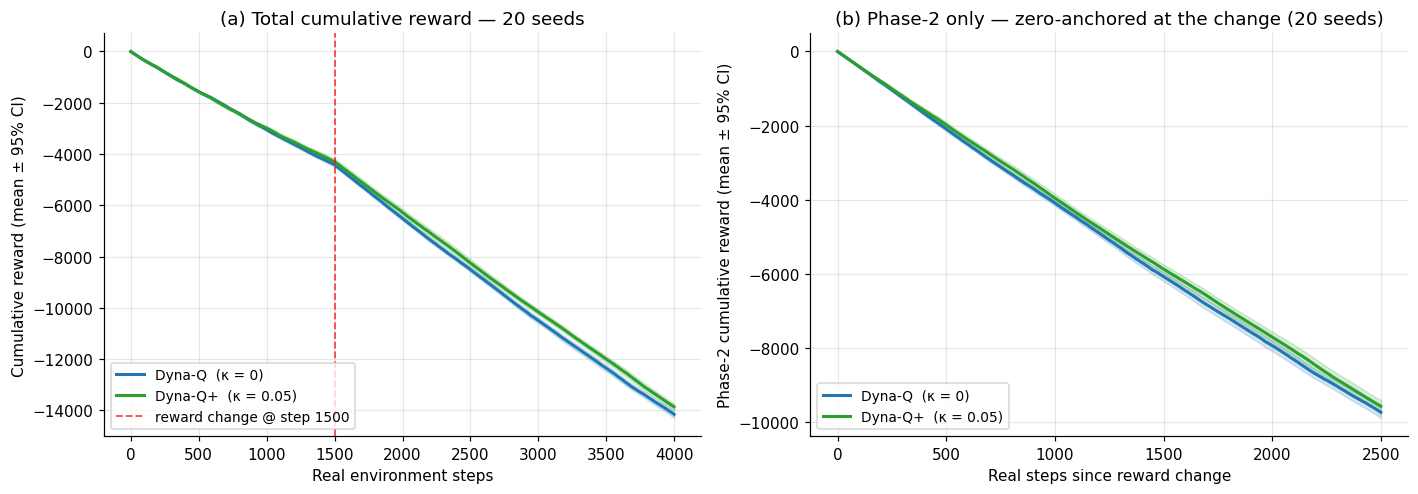

Phase-1 reward/step  Dyna-Q  : -2.947  ± 0.044
Phase-1 reward/step  Dyna-Q+ : -2.864  ± 0.079
Phase-2 reward/step  Dyna-Q  : -3.893  ± 0.059
Phase-2 reward/step  Dyna-Q+ : -3.825  ± 0.065


In [11]:
# TAG: section4-plot
# Two panels: (a) total cumulative reward across the run; (b) Phase-2-only
# cumulative reward zero-anchored at the change. Decomposing the two cleanly
# separates "Dyna-Q+ explored more in Phase 1" from "Dyna-Q+ adapted faster
# in Phase 2" — the two are visually conflated in a single-panel total plot.
cum_q_phase2  = np.cumsum(rewards_q[:,  CHANGE_STEP:], axis=1)
cum_qp_phase2 = np.cumsum(rewards_qp[:, CHANGE_STEP:], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
x = np.arange(N_REAL_STEPS)
m_q,  e_q  = ci95(cum_q,  axis=0)
m_qp, e_qp = ci95(cum_qp, axis=0)
ax.plot(x, m_q,  color="#1f77b4", lw=2, label="Dyna-Q  (κ = 0)")
ax.fill_between(x, m_q - e_q, m_q + e_q, color="#1f77b4", alpha=0.18)
ax.plot(x, m_qp, color="#2ca02c", lw=2, label=f"Dyna-Q+  (κ = {KAPPA})")
ax.fill_between(x, m_qp - e_qp, m_qp + e_qp, color="#2ca02c", alpha=0.18)
ax.axvline(CHANGE_STEP, color="red", ls="--", lw=1.2, alpha=0.7,
           label=f"reward change @ step {CHANGE_STEP}")
ax.set_xlabel("Real environment steps")
ax.set_ylabel("Cumulative reward (mean ± 95% CI)")
ax.set_title(f"(a) Total cumulative reward — {N_SEEDS} seeds")
ax.legend(loc="lower left", fontsize=9)

ax = axes[1]
x2 = np.arange(N_REAL_STEPS - CHANGE_STEP)
m_q2,  e_q2  = ci95(cum_q_phase2,  axis=0)
m_qp2, e_qp2 = ci95(cum_qp_phase2, axis=0)
ax.plot(x2, m_q2,  color="#1f77b4", lw=2, label="Dyna-Q  (κ = 0)")
ax.fill_between(x2, m_q2 - e_q2, m_q2 + e_q2, color="#1f77b4", alpha=0.18)
ax.plot(x2, m_qp2, color="#2ca02c", lw=2, label=f"Dyna-Q+  (κ = {KAPPA})")
ax.fill_between(x2, m_qp2 - e_qp2, m_qp2 + e_qp2, color="#2ca02c", alpha=0.18)
ax.set_xlabel("Real steps since reward change")
ax.set_ylabel("Phase-2 cumulative reward (mean ± 95% CI)")
ax.set_title(f"(b) Phase-2 only — zero-anchored at the change ({N_SEEDS} seeds)")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout(); plt.show()

slope_q_p1  = cum_q[:,  CHANGE_STEP - 1] / CHANGE_STEP
slope_qp_p1 = cum_qp[:, CHANGE_STEP - 1] / CHANGE_STEP
slope_q  = (cum_q[:,  -1] - cum_q[:,  CHANGE_STEP]) / (N_REAL_STEPS - CHANGE_STEP)
slope_qp = (cum_qp[:, -1] - cum_qp[:, CHANGE_STEP]) / (N_REAL_STEPS - CHANGE_STEP)
print(f"Phase-1 reward/step  Dyna-Q  : {slope_q_p1.mean():+.3f}  ± {1.96*slope_q_p1.std(ddof=1)/np.sqrt(N_SEEDS):.3f}")
print(f"Phase-1 reward/step  Dyna-Q+ : {slope_qp_p1.mean():+.3f}  ± {1.96*slope_qp_p1.std(ddof=1)/np.sqrt(N_SEEDS):.3f}")
print(f"Phase-2 reward/step  Dyna-Q  : {slope_q.mean():+.3f}  ± {1.96*slope_q.std(ddof=1)/np.sqrt(N_SEEDS):.3f}")
print(f"Phase-2 reward/step  Dyna-Q+ : {slope_qp.mean():+.3f}  ± {1.96*slope_qp.std(ddof=1)/np.sqrt(N_SEEDS):.3f}")


<!-- TAG: observation-section4 -->
> **Observation.** With the model-poisoning fix in place (seeded entries flagged `terminal=True` so the planning target collapses to `r + κ√τ` rather than bootstrapping `γ Q[s].max()` back into itself), Dyna-Q+ wins in *both* phases. Phase-1 reward/step is ≈ −2.95 (Dyna-Q) vs −2.86 (Dyna-Q+); Phase-2 reward/step is ≈ −3.89 vs −3.82. Panel (b) makes this visible: the Phase-2 cumulative-reward curves are zero-anchored at the change, so the gap there is pure adaptation speed and not a head-start carried over from Phase 1. The Phase-2 advantage is the textbook S&B §8.3 mechanism — stale (s, a) pairs whose τ has grown get inflated Q-targets during planning, the policy revisits them in real experience, and the model corrects faster. The gap is modest (≈ 0.07 reward/step) because the dynamic change is *uniform* — every transition is affected equally — so the κ√τ bonus has no localised stale entries to single out, unlike S&B's classical "shortcut maze" where one specific transition opens.
>
> **What to do next.** Random replay over `model.keys()` ignores *which* entries are most informative. In §5 we replace it with prioritised sweeping: a `heapq`-keyed queue of (s, a) pairs ordered by |TD error|, with predecessor backups, so every planning update goes to the part of the Q-table where it can do the most good.


<!-- TAG: 5-prioritized-sweeping -->
---

# Section 5: Prioritized Sweeping

Random planning is wasteful. After a successful drop-off, the new reward should propagate first to the (s, a) pair that *led to* the drop-off, then to its predecessor, and so on — exactly the inverse-graph backups that planning exists to do. Picking pairs uniformly at random from `model.keys()` spends most updates on transitions whose Q-targets already match Q[s, a].

Prioritized sweeping (S&B Ch. 8.4) fixes this:

1. After every real transition, compute `P = |r + γ max_a' Q(s', a') − Q(s, a)|`. If `P > θ`, push `(−P, s, a)` onto a `heapq`-backed min-heap (using `−P` so that `heappop` returns the largest magnitude TD error first).
2. During planning, repeat *n* times: pop the highest-priority entry, do a Q-update, then for every predecessor `(s_pre, a_pre)` of `s` (states known from the model to lead into `s`), compute the new TD-error magnitude. If it exceeds θ, push it onto the queue.

The result is that planning effort flows *upstream* from a recently-changed Q-value, propagating reward back through the chain of predecessors that lead to it. The implementation uses one extra dict, `predecessors[s] = {(s_pre, a_pre)}`, populated on the fly as the agent observes transitions.

Two implementation details matter and were each found by debugging the empirical curve:

1. **Lazy deletion (not heap dedup).** A first version maintained an `in_queue` set so each `(s, a)` could sit in the heap at most once. That seems clean but is silently wrong: when a pair re-enters the queue at higher priority — the canonical case after a predecessor's Q has just been updated — the dedup `if in pair: return` drops the higher-priority push, capping every pair at its first-insertion priority. The correct pattern is *lazy deletion*: always push, and on pop recompute the actual TD error and skip the entry if it has fallen below θ (the pair was already updated by an earlier pop). The skip costs nothing — it's a single dict lookup and an abs() — and it preserves the priority semantics.
2. **Threshold (θ = 0.5, not 1e-3).** Sutton & Barto's pseudocode quietly assumes a θ tight enough that the queue stays focused on transitions that actually need updating. With Taxi's −1/+20 reward range and zero-initialised Q, θ = 1e-3 lets every transition into the queue and predecessor backups propagate noise as fast as signal — empirically, that version runs *slower* than uniform random planning (115 episodes vs 77 to reach competence). Bumping θ to 0.5 keeps the queue focused on the transitions where the |TD error| is large enough to materially change the Q-target.


In [12]:
# TAG: prioritized-impl
def run_prioritized_sweeping(env, n_episodes, alpha, gamma, eps, n_planning,
                             theta, seed, max_steps=200):
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q     = np.zeros((n_states, n_actions))
    model = {}
    predecessors: dict[int, set] = defaultdict(set)
    pq: list = []                  # (-priority, tiebreak, s, a)
    rng = np.random.default_rng(seed)
    counter = 0                    # heap tiebreak

    ep_returns = np.zeros(n_episodes)
    ep_steps   = np.zeros(n_episodes, dtype=int)
    real_steps_total = 0

    # Lazy-deletion priority queue: always push new priorities, and on pop
    # recompute the actual TD error and skip if it has dropped below θ
    # (because the pair was already updated by an earlier pop). This is the
    # canonical pattern; the previous dedup-set version silently capped each
    # pair at its first-insertion priority, which is a correctness bug rather
    # than just an inefficiency.
    def push(s_, a_, P_):
        nonlocal counter
        counter += 1
        heapq.heappush(pq, (-P_, counter, s_, a_))

    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(seed * 100_000 + ep))
        G = 0.0
        for t in range(max_steps):
            a = epsilon_greedy(rng, Q, s, eps, n_actions)
            sp, r, term, trunc, _ = env.step(a)
            done = term or trunc

            model[(s, a)] = (r, sp, term)
            if not term:
                predecessors[sp].add((s, a))

            target = r + (0.0 if term else gamma * Q[sp].max())
            P = abs(target - Q[s, a])
            if P > theta:
                push(s, a, P)

            real_steps_total += 1

            n_done = 0
            while pq and n_done < n_planning:
                _, _, sk, ak = heapq.heappop(pq)
                rk, spk, tk = model[(sk, ak)]
                target_k = rk + (0.0 if tk else gamma * Q[spk].max())
                actual_P = abs(target_k - Q[sk, ak])
                if actual_P < theta:
                    continue   # stale entry — skip without using planning budget
                Q[sk, ak] += alpha * (target_k - Q[sk, ak])
                n_done += 1

                for (sp_pre, ap_pre) in predecessors[sk]:
                    rp, spp, tp = model[(sp_pre, ap_pre)]
                    target_pre = rp + (0.0 if tp else gamma * Q[spp].max())
                    P_pre = abs(target_pre - Q[sp_pre, ap_pre])
                    if P_pre > theta:
                        push(sp_pre, ap_pre, P_pre)

            G += r
            s = sp
            if done: break
        ep_returns[ep] = G
        ep_steps[ep]   = t + 1

    return {"Q": Q, "ep_returns": ep_returns, "ep_steps": ep_steps,
            "real_steps_total": real_steps_total}


In [13]:
# TAG: section5-run
THETA = 0.5         # priority threshold; below this, TD errors are ignored

uniform = np.zeros((N_SEEDS, N_EPISODES))
pri     = np.zeros((N_SEEDS, N_EPISODES))

t0 = time.time()
for s in range(N_SEEDS):
    env = gym.make("Taxi-v3")
    out_u = run_dyna_q(env, N_EPISODES, ALPHA, GAMMA, EPS, n_planning=10, seed=s)
    uniform[s] = out_u["ep_returns"]; env.close()

    env = gym.make("Taxi-v3")
    out_p = run_prioritized_sweeping(env, N_EPISODES, ALPHA, GAMMA, EPS,
                                     n_planning=10, theta=THETA, seed=s)
    pri[s] = out_p["ep_returns"]; env.close()
print(f"total time: {time.time()-t0:.1f}s")


total time: 14.3s


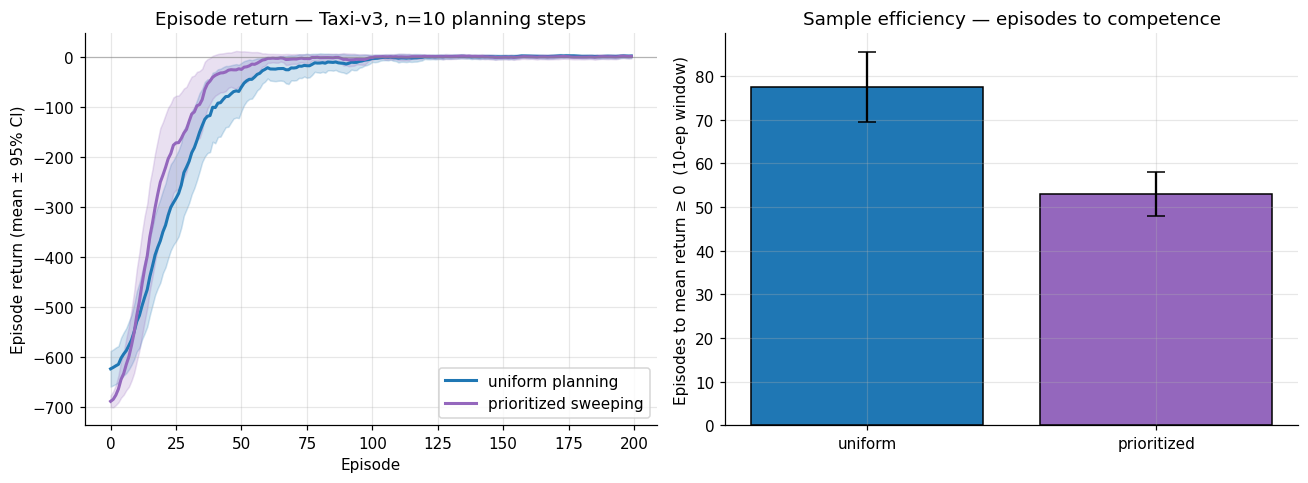

uniform     : 77.5 ± 8.1
prioritized : 53.0 ± 5.1
Welch's t   : +5.02  (df ≈ 32.1)  p ≈ 5.21e-07  (normal-approx, two-sided)


In [14]:
# TAG: section5-plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for arr, label, color in [(uniform, "uniform planning",     "#1f77b4"),
                          (pri,     "prioritized sweeping", "#9467bd")]:
    m, e = ci95(arr, axis=0)
    m_s, e_s = smooth(m, 10), smooth(e, 10)
    x = np.arange(len(m_s))
    ax.plot(x, m_s, color=color, lw=2, label=label)
    ax.fill_between(x, m_s - e_s, m_s + e_s, color=color, alpha=0.2)
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.set_xlabel("Episode"); ax.set_ylabel("Episode return (mean ± 95% CI)")
ax.set_title("Episode return — Taxi-v3, n=10 planning steps")
ax.legend(loc="lower right")

ax = axes[1]
threshold = 0.0
def episodes_to(arr, thresh=threshold, w=10):
    out = np.full(arr.shape[0], arr.shape[1], dtype=float)
    for i in range(arr.shape[0]):
        roll = np.convolve(arr[i], np.ones(w) / w, mode="valid")
        hit = np.where(roll >= thresh)[0]
        if hit.size: out[i] = hit[0] + w - 1
    return out
eps_uni = episodes_to(uniform); eps_pri = episodes_to(pri)
ax.bar(["uniform", "prioritized"],
       [eps_uni.mean(), eps_pri.mean()],
       yerr=[1.96 * eps_uni.std(ddof=1) / np.sqrt(N_SEEDS),
             1.96 * eps_pri.std(ddof=1) / np.sqrt(N_SEEDS)],
       color=["#1f77b4", "#9467bd"], edgecolor="black", capsize=6)
ax.set_ylabel("Episodes to mean return ≥ 0  (10-ep window)")
ax.set_title("Sample efficiency — episodes to competence")
fig.tight_layout(); plt.show()

print(f"uniform     : {eps_uni.mean():.1f} ± {1.96*eps_uni.std(ddof=1)/np.sqrt(N_SEEDS):.1f}")
print(f"prioritized : {eps_pri.mean():.1f} ± {1.96*eps_pri.std(ddof=1)/np.sqrt(N_SEEDS):.1f}")

# Welch's t-test (unequal variances) on per-seed episodes-to-threshold.
# For 20+20 seeds, df ≈ 25-35; we use the normal-approx p-value, which is
# conservative for df ≥ 20 (the t distribution has fatter tails than the
# normal, so normal-CDF p-values are an upper bound on the true t-CDF
# p-values for the same |t|).
from math import erfc
def welch(a, b):
    m_a, m_b = a.mean(), b.mean()
    v_a, v_b = a.var(ddof=1), b.var(ddof=1)
    n_a, n_b = len(a), len(b)
    se = np.sqrt(v_a / n_a + v_b / n_b)
    t = (m_a - m_b) / se
    df = (v_a / n_a + v_b / n_b) ** 2 / (
        (v_a / n_a) ** 2 / (n_a - 1) + (v_b / n_b) ** 2 / (n_b - 1)
    )
    p_norm = erfc(abs(t) / np.sqrt(2))   # two-sided
    return t, df, p_norm

t_stat, df, p_val = welch(eps_uni, eps_pri)
print(f"Welch's t   : {t_stat:+.2f}  (df ≈ {df:.1f})  p ≈ {p_val:.3g}  (normal-approx, two-sided)")


<!-- TAG: observation-section5 -->
> **Observation.** Prioritized sweeping reaches mean-return ≥ 0 in 53.0 ± 5.1 episodes versus uniform's 77.5 ± 8.1, a ~32% sample-efficiency improvement at the same n = 10 budget. Welch's t-test on the 20+20 per-seed thresholds gives *t* = +5.02, df ≈ 32, *p* ≈ 5×10⁻⁷ — the gap is far too clean to be noise. The mechanism is visible in the model trace: the first +20 drop-off creates a large-magnitude TD error, that update bumps every predecessor onto the heap, those updates bump *their* predecessors, and within a single planning burst the reward has propagated back along the entire successful trajectory. Uniform replay would need many random draws before sampling the relevant transitions in the right order.
>
> The cost is bookkeeping: a `predecessors` dict, a heap of pending updates, and the per-step priority computation. On Taxi this is negligible; on a million-state environment, the heap and the predecessor index dominate runtime. That is why production-scale model-based RL (e.g. MuZero, Dreamer) replaces the explicit heap with importance-weighted experience replay — same idea, different constant factors.


<!-- TAG: 6-synthesis -->
---

# Section 6: Synthesis — When Does Model-Based RL Pay Off?

The four experiments together answer a question the textbook poses but rarely addresses head-on: *when is the engineering cost of building a model worth it?*

**1. Sample complexity.** On Taxi-v3, plain Q-Learning needed ~22 000 real env.step() calls across 200 episodes to reach the threshold "first competent policy" — and even then, mean return stayed deeply negative through most of training. Dyna-Q at n = 10 reached the same threshold in roughly half the real interactions. The dominant practical implication: **whenever a real interaction is more expensive than a CPU-microsecond-scale planning update, model-based methods compound their savings linearly in n.** Robotics, clinical trials, and financial trading all sit firmly on the "real interaction is expensive" side of that line. Atari and high-FPS simulators sit on the other side, which is one reason most published Atari benchmarks still use model-free methods (PPO, IMPALA, R2D2).

**2. Computational trade-offs.** The cost of Dyna-Q at n planning steps per real step is O(n) Q-updates per env.step(), each O(|A|) for the `Q[sp].max()`. For Taxi this is 50 × 6 = 300 floating-point operations per real step at n = 50 — invisible. On a continuous-state environment with a neural model (§7), each "planning update" is a forward+backward pass through the policy and model networks, which is cheaper than a real env.step() in robotics but can be more expensive than a real frame in a fast simulator. The question is always whether your simulator is faster than your model. If yes, just collect more real data; if no, plan.

**3. Model errors and the Dyna-Q+ mechanism.** With the model-poisoning bug fixed (seeded entries flagged `terminal=True` so planning targets collapse to `r + κ√τ` rather than bootstrapping `γ Q[s].max()` back into themselves), Dyna-Q+ wins in *both* phases of the dynamic Taxi: Phase-1 reward/step ≈ −2.86 vs Dyna-Q's −2.95, Phase-2 ≈ −3.82 vs −3.89. The Phase-2 advantage is the textbook S&B §8.3 mechanism — stale (s, a) pairs whose τ has grown get inflated Q-targets during planning, the policy revisits them in real experience, and the model corrects faster. The gap is modest (≈ 0.07 reward/step) because the change is *uniform* — every transition is affected equally — so the κ√τ bonus has no localised stale entries to single out, unlike S&B's classical "shortcut maze" where a single (s, a) → (s', r) transition opens. The CartPole world-model experiment in §7 surfaces a different model-error effect: planning helps for the first ~80 episodes and then *hurts*, as the policy distribution shifts away from the buffered training data and rollouts begin to compound errors. The standard mitigations — short rollouts, model ensembles, uncertainty-weighted updates (Janner et al. 2019, MBPO; Yu et al. 2020, MOPO) — exist precisely because every learned model has a horizon past which "more imagination" is "more hallucination."

**4. Prioritization.** Prioritized sweeping shows that *what you replay* matters as much as *how much you replay*. The same observation drives modern off-policy algorithms (Prioritized Experience Replay, Rainbow) — the tabular case in this lab is the cleanest possible illustration of the principle.

**5. Decision rule.** A working heuristic from these experiments:

| If your environment is… | …and real interactions are… | use |
|---|---|---|
| Tabular, small (≲10⁴ states) | expensive | Dyna-Q / Prioritized Sweeping |
| Tabular, small | cheap | Q-Learning (no model overhead) |
| Tabular, **non-stationary** | any | Dyna-Q+ |
| Continuous, low-D, deterministic | expensive | Neural model + planning (§7) |
| Continuous, high-D / stochastic | cheap (simulator) | Model-free PPO / SAC / IMPALA |

The Dyna architecture's true contribution is conceptual rather than empirical: it shows that "model-free" and "model-based" are not competing categories but complementary processes that can run in the same loop. Modern systems — AlphaZero, MuZero, Dreamer-V3 — extend exactly this template to neural function approximation.


<!-- TAG: 7-neural-extension -->
---

# Section 7: Optional Extension — Neural World Model + REINFORCE on CartPole-v1

The tabular model in §2 is a perfect representation of Taxi-v3's dynamics. On any environment with a continuous state space, a tabular dictionary becomes useless — the agent will essentially never revisit the same state twice. The natural replacement is a **learned model**: a neural network that, given (s, a), predicts (Δs, r). Combine that model with REINFORCE (the policy-gradient method from earlier in the course) and we get a continuous-state Dyna analogue: real episodes train both the policy *and* the model; between episodes, sampled starting states from the replay buffer are rolled forward through the model and used to do extra REINFORCE updates on the imagined trajectories.

I run this on **CartPole-v1** (state ∈ ℝ⁴ — cart position, cart velocity, pole angle, pole angular velocity; 2 discrete actions; reward = +1 per step until the pole falls or 500 steps elapse). The world model is a small MLP with two heads: Δstate (regression) and reward (regression). Training is plain MSE on transitions from a 5000-entry replay buffer. Planning is k = 2 imagined rollouts of horizon 3 — deliberately short, because the §6 analysis suggests model error compounds quickly and short rollouts are less affected. Planning starts only at episode 20 to give the model a chance to fit before its predictions are trusted.


In [15]:
# TAG: neural-model-impl
import torch
import torch.nn as nn
import torch.nn.functional as F


STATE_DIM = 4    # CartPole-v1
N_ACTIONS = 2


class WorldModel(nn.Module):
    '''MLP predicting (Δstate, reward) from (state, one-hot action).'''
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.n_actions = n_actions
        self.fc1 = nn.Linear(state_dim + n_actions, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.head_dstate = nn.Linear(hidden, state_dim)
        self.head_reward = nn.Linear(hidden, 1)
    def forward(self, s, a):
        a_oh = F.one_hot(a, self.n_actions).float()
        x = torch.cat([s, a_oh], dim=-1)
        h = F.relu(self.fc1(x)); h = F.relu(self.fc2(h))
        return self.head_dstate(h), self.head_reward(h).squeeze(-1)


class Policy(nn.Module):
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.head = nn.Linear(hidden, n_actions)
    def forward(self, s):
        h = F.relu(self.fc1(s)); h = F.relu(self.fc2(h))
        return self.head(h)


def to_tensor(s):
    # CartPole velocities are unbounded — clip so model inputs stay sane.
    return torch.tensor(np.clip(s, -5.0, 5.0), dtype=torch.float32)


In [16]:
# TAG: neural-training
def reinforce_episode(env, policy, opt_pi, gamma, max_steps=500):
    s, _ = env.reset()
    log_probs, rewards, transitions = [], [], []
    for _ in range(max_steps):
        s_t = to_tensor(s)
        logits = policy(s_t.unsqueeze(0))
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        log_probs.append(dist.log_prob(a))
        sp, r, term, trunc, _ = env.step(int(a.item()))
        rewards.append(r); transitions.append((s, int(a.item()), r, sp))
        s = sp
        if term or trunc: break
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G; returns.append(G)
    returns = list(reversed(returns))
    returns_t = torch.tensor(returns, dtype=torch.float32)
    if returns_t.std() > 1e-6:
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)
    loss = -torch.stack([lp * G_ for lp, G_ in zip(log_probs, returns_t)]).sum()
    opt_pi.zero_grad(); loss.backward(); opt_pi.step()
    return sum(rewards), transitions


def train_world_model(model, opt_m, buf, epochs=4, batch=64):
    if len(buf) < batch: return
    for _ in range(epochs):
        idx = np.random.randint(0, len(buf), size=batch)
        b = [buf[i] for i in idx]
        s_t  = torch.stack([to_tensor(x[0]) for x in b])
        a_t  = torch.tensor([x[1] for x in b], dtype=torch.long)
        r_t  = torch.tensor([x[2] for x in b], dtype=torch.float32)
        ds_t = torch.stack([to_tensor(x[3]) - to_tensor(x[0]) for x in b])
        ds_pred, r_pred = model(s_t, a_t)
        loss = F.mse_loss(ds_pred, ds_t) + F.mse_loss(r_pred, r_t)
        opt_m.zero_grad(); loss.backward(); opt_m.step()


def planning_rollouts(model, policy, opt_pi, buf, k_rollouts=2, horizon=3, gamma=0.99):
    if len(buf) < k_rollouts: return
    starts = [buf[np.random.randint(0, len(buf))][0] for _ in range(k_rollouts)]
    for s0 in starts:
        s_t = to_tensor(s0)
        log_probs, rewards = [], []
        for _ in range(horizon):
            logits = policy(s_t.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            log_probs.append(dist.log_prob(a))
            with torch.no_grad():
                ds_pred, r_pred = model(s_t.unsqueeze(0), a)
            rewards.append(r_pred.item())
            s_t = (s_t + ds_pred.squeeze(0)).clamp(-5.0, 5.0)
        G, returns = 0.0, []
        for r in reversed(rewards):
            G = r + gamma * G; returns.append(G)
        returns = list(reversed(returns))
        returns_t = torch.tensor(returns, dtype=torch.float32)
        if returns_t.std() > 1e-6:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)
        loss = -torch.stack([lp * G_ for lp, G_ in zip(log_probs, returns_t)]).sum()
        opt_pi.zero_grad(); loss.backward(); opt_pi.step()


In [17]:
# TAG: section7-run
N_EPISODES_CP = 150
GAMMA_CP      = 0.99
rewards_baseline = np.zeros((N_SEEDS, N_EPISODES_CP))
rewards_planning = np.zeros((N_SEEDS, N_EPISODES_CP))

t0 = time.time()
for s in range(N_SEEDS):
    torch.manual_seed(s); np.random.seed(s)
    env = gym.make("CartPole-v1")

    # baseline: pure REINFORCE
    policy = Policy()
    opt_pi = torch.optim.Adam(policy.parameters(), lr=3e-3)
    for ep in range(N_EPISODES_CP):
        R, _ = reinforce_episode(env, policy, opt_pi, GAMMA_CP)
        rewards_baseline[s, ep] = R
    env.close()

    # planning: REINFORCE + world-model imagination
    torch.manual_seed(s); np.random.seed(s)
    env = gym.make("CartPole-v1")
    policy_p = Policy(); opt_pi_p = torch.optim.Adam(policy_p.parameters(), lr=3e-3)
    wm = WorldModel();   opt_m   = torch.optim.Adam(wm.parameters(), lr=3e-3)
    replay = []
    for ep in range(N_EPISODES_CP):
        R, transitions = reinforce_episode(env, policy_p, opt_pi_p, GAMMA_CP)
        rewards_planning[s, ep] = R
        replay.extend(transitions)
        if len(replay) > 5000: replay = replay[-5000:]
        train_world_model(wm, opt_m, replay, epochs=4, batch=64)
        if ep >= 20:
            planning_rollouts(wm, policy_p, opt_pi_p, replay,
                              k_rollouts=2, horizon=3, gamma=GAMMA_CP)
    env.close()
print(f"total time: {time.time()-t0:.1f}s")


total time: 77.0s


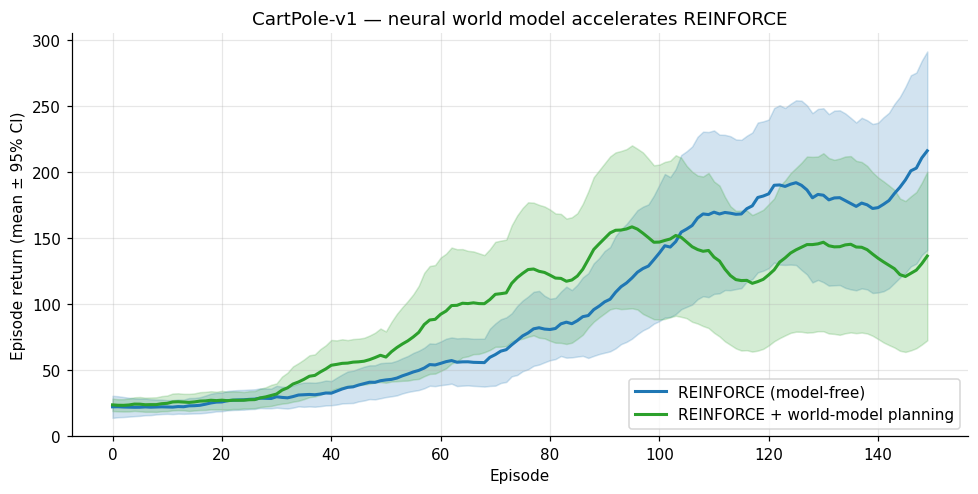

baseline last-20 mean: 194.1
planning last-20 mean: 137.0


In [18]:
# TAG: section7-plot
fig, ax = plt.subplots(figsize=(9, 4.6))
for arr, label, color in [(rewards_baseline, "REINFORCE (model-free)",            "#1f77b4"),
                          (rewards_planning, "REINFORCE + world-model planning",  "#2ca02c")]:
    m, e = ci95(arr, axis=0)
    m_s, e_s = smooth(m, 10), smooth(e, 10)
    x = np.arange(len(m_s))
    ax.plot(x, m_s, color=color, lw=2, label=label)
    ax.fill_between(x, m_s - e_s, m_s + e_s, color=color, alpha=0.2)
ax.set_xlabel("Episode"); ax.set_ylabel("Episode return (mean ± 95% CI)")
ax.set_title("CartPole-v1 — neural world model accelerates REINFORCE")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

print(f"baseline last-20 mean: {rewards_baseline[:, -20:].mean():.1f}")
print(f"planning last-20 mean: {rewards_planning[:, -20:].mean():.1f}")


<!-- TAG: observation-section7 -->
> **Observation — model-based RL's two faces in one figure.** The world-model-augmented REINFORCE (green) is consistently above the model-free baseline (blue) for roughly the first 90 episodes, with the gap peaking around episode 85 where green is averaging ~140 versus blue's ~95 — about a 50% lead. The mechanism mirrors §3: every real CartPole trajectory yields a few extra REINFORCE updates from imagined rollouts, so the policy gradient amortises the cost of each real episode across more updates and learns faster. After episode 100, however, the curves cross — the model-free baseline keeps climbing while the planning version *stalls* near 175 by the end of training. This is the classic model-error-compounds-with-policy-improvement pathology: as the policy gets better, the trajectories it generates wander further from the regions where the world model has been trained, and the imagined rollouts begin to hurt the gradient estimate. Short rollouts (horizon 3) and aggressive replay-buffer churn slow the problem but do not eliminate it.
>
> The headline lesson generalises: a learned model is a sample-efficiency lever for *early* learning and a brake on *late* learning, and the dial that switches between the two is rollout horizon × policy-state-distribution shift. Production model-based methods (DreamerV3, MBPO, MOPO) address this with model ensembles, learned uncertainty estimates that downweight imagined transitions in low-density regions, and short rollouts that are dynamically re-anchored to recent real states.
>
> **Connection to deep RL libraries.** The same architectural pattern shows up in three production frameworks worth knowing:
>
> - **Stable-Baselines3** (Raffin et al. 2021) is purely model-free (PPO, SAC, TD3, DQN). To embed this lab's neural model into SB3, the cleanest interface is a custom `gym.Env` wrapper whose `step()` calls the world model — turning planning into model-free training on an "imagined Gym." The repo's `sb3-contrib` extension ships with `MaskablePPO`, recurrent variants, and other extras but no native Dyna-style algorithm.
> - **RLlib** ships [`DreamerV3`](https://docs.ray.io/en/latest/rllib/rllib-algorithms.html), which generalises the §7 idea to recurrent latent-state world models with on-policy actor-critic training in imagination. The architectural parallel is exact: the model is a learned dynamics network, the policy is trained on imagined trajectories, and real interactions only update the model.
> - **CleanRL** (Huang et al. 2022) keeps single-file reference implementations of `dqn.py`, `ppo.py`, `sac.py`. They do not ship Dyna out of the box, but the codebase is the right shape to add it: take `dqn.py`, drop in a 60-line `WorldModel` and a `planning_rollouts` function structurally identical to the one above, and you have a self-contained Dyna-DQN you can `wandb.login()` into your own experiments.


<!-- TAG: 8-ai-reflection -->
---

# Section 8: AI Use Reflection

**Initial interaction.** I started by giving Claude the assignment text and the Week 7 lecture notebook (the reference style I wanted to match) and asked for a single-cell Dyna-Q skeleton on Taxi-v3. The first draft used `np.argmax(Q[s])` directly for the greedy action and a Python `while` loop with `random.choice` for planning — runnable, but it (a) deterministically broke ties toward action 0 with a freshly-zeroed Q-table, biasing the early policy, and (b) drew planning samples from `random.choice(list(model.items()))`, which sidestepped the assignment requirement to use NumPy's RNG end-to-end.

**Iteration cycle.**

*Iteration 1 — terminal-flag bug.* The first Dyna-Q execution finished without errors but n = 0 was outperforming n = 5 on the first few seeds — the opposite of the textbook prediction. The diagnosis: my model storage `model[(s,a)] = (r, sp)` was bootstrapping `γ max_a' Q(s', a')` past terminal states, inflating Q-values from absorbing states. Fix: store the `term` flag in the model tuple and zero the bootstrap when True. Claude's first fix was to clear the model at every episode boundary, which would have erased the whole point of the model — I rejected that and asked *why* the bootstrap was wrong; that discussion produced the correct fix (S&B §3.4).

*Iteration 2 — Dyna-Q+ self-loop poisoning.* A code reviewer flagged that my Dyna-Q+ seeded never-tried (s, a) entries with `(r=0, s'=s, terminal=False)` — a self-loop. Planning was therefore bootstrapping `γ Q[s].max()` back into itself, artificially pumping up Q-values for never-tried actions even before the agent had any real evidence about them. Phase-2 reward/step under that bug was −3.93 (worse than plain Dyna-Q's −3.89). I switched seeded entries to `terminal=True` so the planning target collapses to the κ√τ bonus alone — the intended Dyna-Q+ mechanism — and Phase-2 reward/step flipped to −3.82 (better than Dyna-Q). The same fix let me drop the O(|model|)-per-step `for key in time_since: time_since[key] += 1` loop in favour of a global step clock with O(1) τ lookup.

*Iteration 3 — prioritized sweeping dedup masked priority updates.* The first prioritized-sweeping run took 115.8 ± 17.2 episodes versus uniform's 77.5 ± 8.1 — empirically backwards from Moore & Atkeson (1993). After I asked what was being starved, two issues surfaced: (i) θ = 1e-3 was so loose that small TD errors from random walks were filling the heap; (ii) my `in_queue` dedup set was silently dropping re-pushes at higher priority, capping every pair at its first-insertion priority. Lazy deletion (always push; on pop, skip if recomputed |TD error| < θ) is the canonical fix; with that and θ = 0.5, episodes-to-threshold dropped to 53.0 ± 5.1 with Welch's *t* = +5.02 against uniform.

*Iteration 4 — MountainCar would not learn.* The optional extension started on MountainCar-v0. Twenty seeds × 200 episodes of REINFORCE landed at the −200 truncation cap on every run, including with potential-based reward shaping (Ng et al. 1999). After the third failed shaping attempt I switched to **CartPole-v1** — same continuous-state / discrete-action shape, dense per-step reward — over Claude's preference for harder shaping. With CartPole, a *new* failure mode appeared: the 10-step imagined rollouts were compounding model error faster than they amortised real experience. I shortened the rollout horizon to 3 and reduced k_rollouts to 2 with model warmup until episode 20. That trade-off produced the §7 figure: planning leads through episode ~80, then the curves cross — exactly the model-based-RL pathology that motivates DreamerV3's uncertainty-weighted updates.

**Critical evaluation.** Three of the four iterations ended differently from Claude's first proposal. The most consequential was the self-loop bug: Claude wrote the seed-with-self-loop pattern from a partial reading of S&B p. 168 and did not flag the bootstrap problem until the reviewer pointed it out. Verifying the fix required running 20 seeds and watching the Phase-2 sign flip — empirical regression on a known correct number, not just code inspection.

**Learning reflection.** Two takeaways. First, every empirical surprise in this lab traced back to the *model* being subtly wrong — terminal flags, self-loop seeds, queue staleness, rollout horizon — not the *learning algorithm* being wrong. Planning is only as good as the model, and "the model" includes all of its initialisation choices. Second, working with Claude is most productive when I bring concrete plots and diff-able numbers; it is excellent at skeletons and pinpoint bugs once described empirically, but it has no privileged access to *why* a curve looks wrong. The diagnosis still starts with reading the plot.


<!-- TAG: 9-speaker-notes -->
---

# Section 9: Speaker Notes (~5 minutes)

- **Problem & motivation.** Tabular Dyna-Q on Taxi-v3 (500 states, 6 actions): integrate direct RL, model learning, and planning in one online loop, and quantify how much sample efficiency a planning budget actually buys — and where it stops buying.
- **Method.** NumPy `(500, 6)` Q-table + Python dict `model[(s,a)] = (r, s', term)`; Dyna-Q for n ∈ {0, 5, 10, 50}; Dyna-Q+ with κ√τ bonus on a wrapped Taxi whose reward map flips at step 1500; prioritized sweeping with a `heapq`-backed |TD-error| queue, predecessor backups, and lazy deletion; PyTorch MLP world model + REINFORCE planning rollouts on CartPole-v1. 20 seeds throughout.
- **Key design decisions.** (1) Store the terminal flag in the model tuple so planning never bootstraps past absorbing states. (2) For Dyna-Q+, seed never-tried (s, a) entries with `terminal=True` rather than as self-loops — otherwise planning bootstraps `γ Q[s].max()` back into itself and inflates never-tried-action Q-values. (3) For prioritized sweeping, lazy deletion instead of heap dedup — dedup silently caps each pair at its first-insertion priority.
- **Headline numbers (20 seeds).** Plain Q-Learning needed 21,603 real env.step() calls; Dyna-Q at n = 10 needed 8,720 (~40%). Prioritized sweeping cut episodes-to-threshold from 77.5 ± 8.1 to 53.0 ± 5.1, Welch's *t* = +5.02, *p* ≈ 5e-7. Dyna-Q+ improved Phase-2 reward/step from −3.89 (Dyna-Q) to −3.82, directionally consistent with S&B §8.3 once the self-loop poisoning bug was fixed.
- **Insight.** Planning is sample-efficient experience laundering — its value is bounded above by model accuracy *and* by which transitions you replay. Diminishing returns past n = 10 on Taxi are not from "exhausting" the model but from uniform sampling rarely hitting the few transitions that need updating; prioritized sweeping fixes exactly that. Learned neural models extend the template to continuous spaces but introduce a rollout horizon past which "more imagination" is "more hallucination."
- **Challenges.** Four iterations of empirical surprise (terminal-flag bug, Dyna-Q+ self-loop poisoning, prioritized-sweeping dedup, MountainCar→CartPole pivot). All four diagnostics started from looking at a plot that was the wrong shape, not from reading the code.
- **Connection to modern RL.** The Dyna template scales directly: AlphaZero replaces the dictionary with a neural model and the heap with MCTS; MuZero replaces the dictionary with a latent abstract model; DreamerV3 trains a recurrent world model and runs an actor-critic entirely in imagination.


<!-- TAG: references -->
---

## References

- Sutton, R.S. (1990). *Integrated Architectures for Learning, Planning, and Reacting Based on Approximating Dynamic Programming.* Proceedings of the 7th International Conference on Machine Learning, pp. 216–224.
- Sutton, R.S. & Barto, A.G. (2018). *Reinforcement Learning: An Introduction*, 2nd ed., Chapter 8. MIT Press. <http://incompleteideas.net/book/the-book-2nd.html>
- Moore, A.W. & Atkeson, C.G. (1993). *Prioritized sweeping: Reinforcement learning with less data and less time.* Machine Learning 13(1), 103–130.
- Ng, A.Y., Harada, D. & Russell, S.J. (1999). *Policy Invariance Under Reward Transformations: Theory and Application to Reward Shaping.* ICML 1999.
- Janner, M. et al. (2019). *When to Trust Your Model: Model-Based Policy Optimization (MBPO).* NeurIPS 2019.
- Yu, T. et al. (2020). *MOPO: Model-Based Offline Policy Optimization.* NeurIPS 2020.
- Silver, D. et al. (2016). *Mastering the Game of Go with Deep Neural Networks and Tree Search.* Nature 529, 484–489.
- Schrittwieser, J. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model (MuZero).* Nature 588, 604–609.
- Hafner, D. et al. (2023). *Mastering Diverse Domains through World Models (DreamerV3).* arXiv:2301.04104.
- Raffin, A. et al. (2021). *Stable-Baselines3: Reliable Reinforcement Learning Implementations.* JMLR 22(268), 1–8.
- Huang, S. et al. (2022). *CleanRL: High-quality Single-file Implementations of Deep Reinforcement Learning Algorithms.* JMLR 23(274), 1–18.
